In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
print("Downloading MNIST data... (this might take a minute)")
mnist = fetch_openml('mnist_784', version=1, as_frame=True)
df = mnist.frame
print("Data loaded successfully!")

Data loaded successfully!


In [3]:
Y_full = df['class'].astype(int).values

X_full = df.drop('class', axis=1).values

m = X_full.shape[0]
indices = np.random.permutation(m)
X_full = X_full[indices]
Y_full = Y_full[indices]

X_full = X_full.T

X_dev = X_full[:, 0:1000] / 255.
Y_dev = Y_full[0:1000]

X_train = X_full[:, 1000:m] / 255.
Y_train = Y_full[1000:m]

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {Y_train.shape}")

Training data shape: (784, 69000)
Training labels shape: (69000,)


In [4]:
def init_params(layer_dims):

    params = {}
    L = len(layer_dims) # Number of layers

    for l in range(1, L):
        params['W' + str(l)] = np.random.rand(layer_dims[l], layer_dims[l-1]) - 0.5
        params['b' + str(l)] = np.random.rand(layer_dims[l], 1) - 0.5

    return params

In [5]:
def ReLU(Z):
    return np.maximum(Z, 0)

def deriv_ReLU(Z):
    return Z > 0

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

In [10]:
def forward_prop(X, params):
    cache = {}
    cache['A0'] = X # Input images
    L = len(params) // 2 # Total number of layers (Weights + Biases divided by 2)

    for l in range(1, L):
        cache['Z' + str(l)] = params['W' + str(l)].dot(cache['A' + str(l-1)]) + params['b' + str(l)]
        cache['A' + str(l)] = ReLU(cache['Z' + str(l)])

    cache['Z' + str(L)] = params['W' + str(L)].dot(cache['A' + str(L-1)]) + params['b' + str(L)]
    cache['A' + str(L)] = softmax(cache['Z' + str(L)])

    return cache

In [7]:
def backward_prop(X, Y, params, cache):
    m = Y.size
    one_hot_Y = one_hot(Y)
    grads = {}
    L = len(params) // 2

    dZ = cache['A' + str(L)] - one_hot_Y
    grads['dW' + str(L)] = 1 / m * dZ.dot(cache['A' + str(L-1)].T)
    grads['db' + str(L)] = 1 / m * np.sum(dZ, axis=1, keepdims=True)


    for l in reversed(range(1, L)):
        dZ = params['W' + str(l+1)].T.dot(dZ) * deriv_ReLU(cache['Z' + str(l)])

        grads['dW' + str(l)] = 1 / m * dZ.dot(cache['A' + str(l-1)].T)
        grads['db' + str(l)] = 1 / m * np.sum(dZ, axis=1, keepdims=True)

    return grads

In [8]:
def update_params(params, grads, alpha):
    L = len(params) // 2
    for l in range(1, L + 1):
        params['W' + str(l)] = params['W' + str(l)] - alpha * grads['dW' + str(l)]
        params['b' + str(l)] = params['b' + str(l)] - alpha * grads['db' + str(l)]
    return params

def get_predictions(A):
    return np.argmax(A, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, layer_dims, alpha, iterations):
    params = init_params(layer_dims)
    L = len(layer_dims) - 1

    for i in range(iterations):
        cache = forward_prop(X, params)
        grads = backward_prop(X, Y, params, cache)
        params = update_params(params, grads, alpha)

        if i % 10 == 0:
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(cache['A' + str(L)]), Y))

    return params

In [16]:
import time

my_architecture = [784, 10, 10, 10]
num_iterations = 500

print("Training the NumPy model from scratch...")
start_time = time.time()

trained_params = gradient_descent(X_train, Y_train, my_architecture, alpha=0.1, iterations=num_iterations)

end_time = time.time()
total_time = end_time - start_time

print(f"\n--- NumPy Training Performance ---")
print(f"Total Training Time: {total_time:.2f} seconds")
print(f"Average Time per Epoch: {total_time / num_iterations:.4f} seconds")

Training the NumPy model from scratch...
Iteration:  0
Accuracy:  0.0913768115942029
Iteration:  10
Accuracy:  0.1277536231884058
Iteration:  20
Accuracy:  0.18636231884057972
Iteration:  30
Accuracy:  0.24744927536231884
Iteration:  40
Accuracy:  0.31123188405797103
Iteration:  50
Accuracy:  0.3562608695652174
Iteration:  60
Accuracy:  0.3848405797101449
Iteration:  70
Accuracy:  0.41981159420289854
Iteration:  80
Accuracy:  0.46160869565217394
Iteration:  90
Accuracy:  0.5026231884057971
Iteration:  100
Accuracy:  0.536840579710145
Iteration:  110
Accuracy:  0.5663913043478261
Iteration:  120
Accuracy:  0.5899855072463768
Iteration:  130
Accuracy:  0.6114782608695652
Iteration:  140
Accuracy:  0.631927536231884
Iteration:  150
Accuracy:  0.6501884057971015
Iteration:  160
Accuracy:  0.6665797101449276
Iteration:  170
Accuracy:  0.680463768115942
Iteration:  180
Accuracy:  0.6937536231884058
Iteration:  190
Accuracy:  0.7048405797101449
Iteration:  200
Accuracy:  0.7149420289855073
It

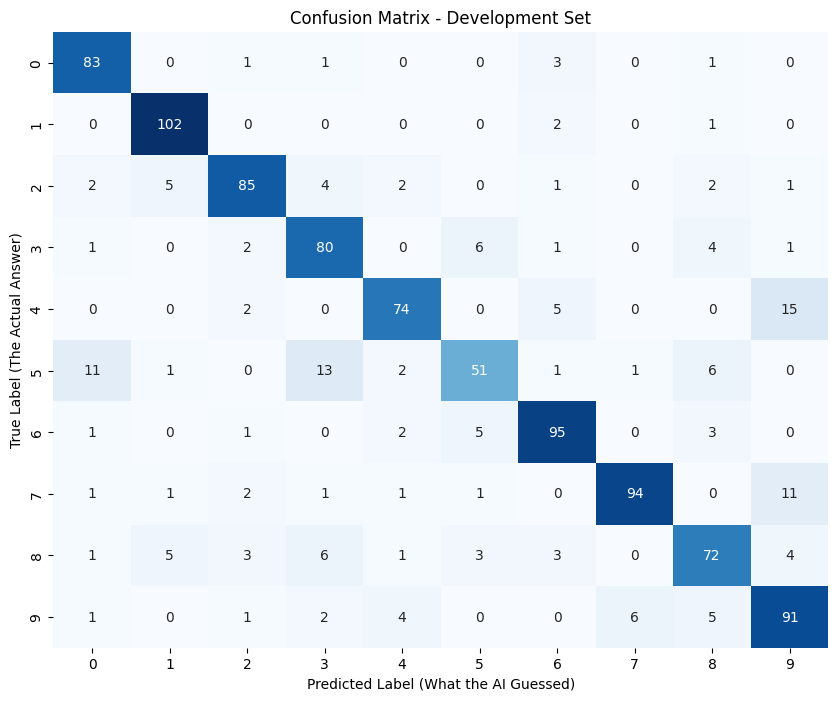

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def predict(X, params):
    cache = forward_prop(X, params)
    L = len(params) // 2
    A_final = cache['A' + str(L)]
    return get_predictions(A_final)

dev_predictions = predict(X_dev, trained_params)

cm = confusion_matrix(Y_dev, dev_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Development Set")
plt.xlabel("Predicted Label (What the AI Guessed)")
plt.ylabel("True Label (The Actual Answer)")
plt.show()

Total mistakes in Dev Set: 173 out of 1000
Displaying 10 Autopsy Candidates:



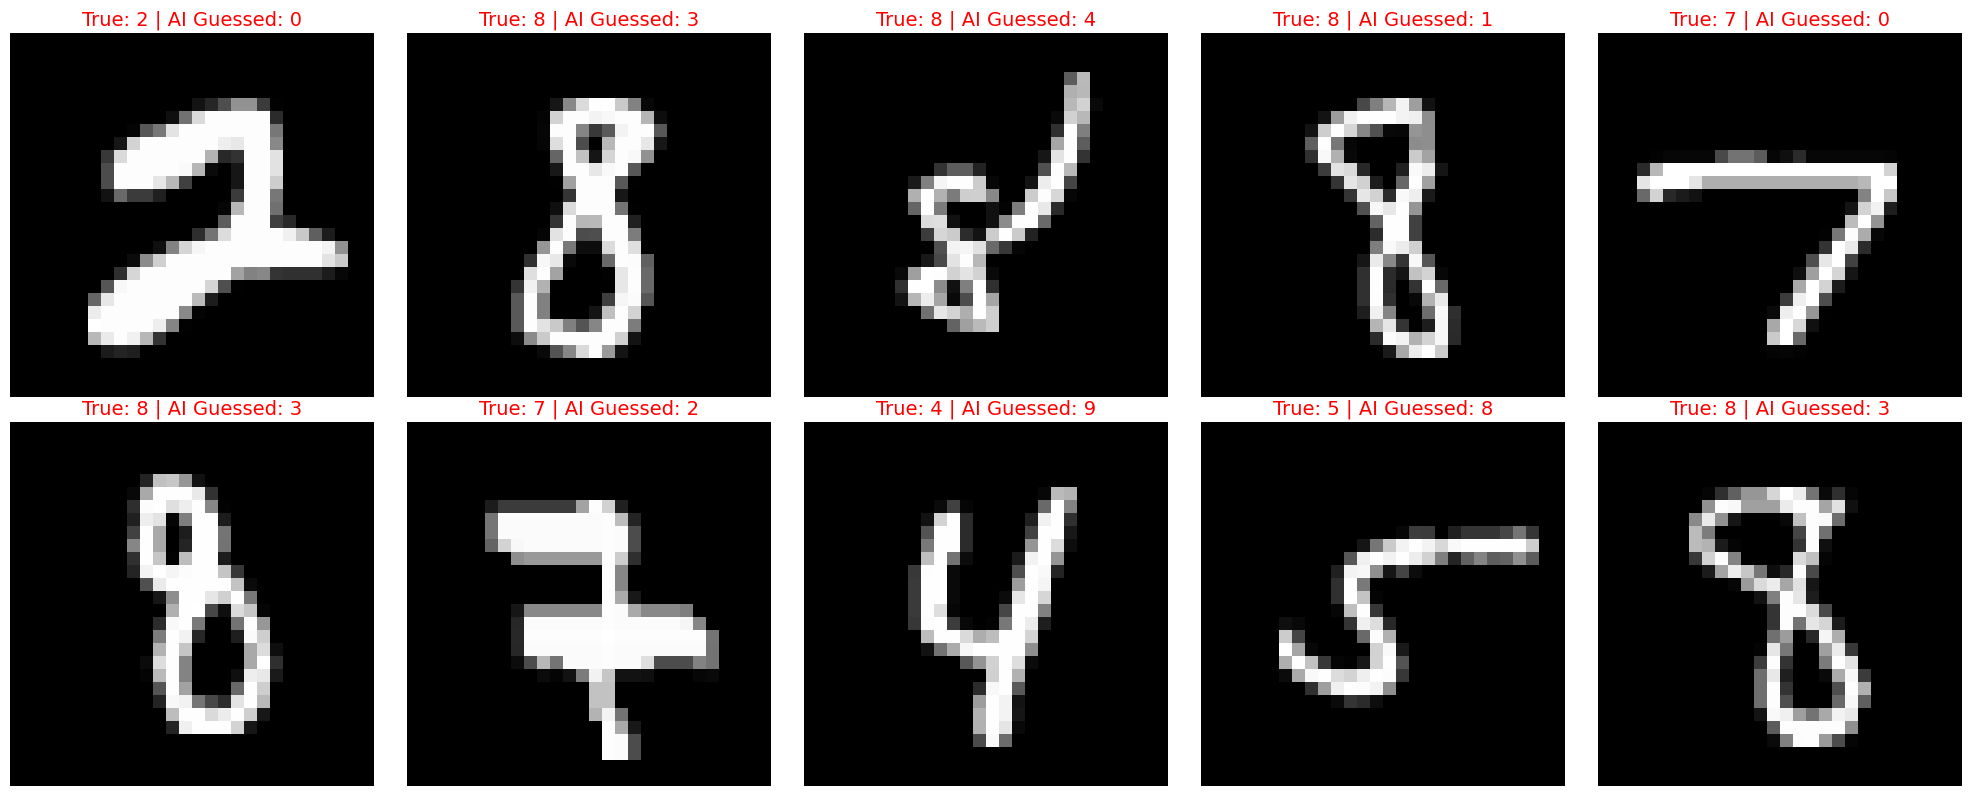

In [14]:
misclassified_indices = np.where(dev_predictions != Y_dev)[0]

sample_mistakes = misclassified_indices[:10]

print(f"Total mistakes in Dev Set: {len(misclassified_indices)} out of {Y_dev.size}")
print("Displaying 10 Autopsy Candidates:\n")

plt.figure(figsize=(20, 8))

for i, index in enumerate(sample_mistakes):
    true_label = Y_dev[index]
    bad_guess = dev_predictions[index]

    digit_pixels = X_dev[:, index].reshape(28, 28)

    plt.subplot(2, 5, i + 1)
    plt.imshow(digit_pixels, cmap='gray')
    plt.title(f"True: {true_label} | AI Guessed: {bad_guess}", fontsize=14, color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
import tensorflow as tf
import time

X_train_keras = X_train.T
X_dev_keras = X_dev.T
print("Building the Keras model...")
keras_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),                # Input Layer (784 pixels)
    tf.keras.layers.Dense(10, activation='relu'),       # Hidden Layer 1 (10 nodes, ReLU)
    tf.keras.layers.Dense(10, activation='relu'),       # Hidden Layer 2 (10 nodes, ReLU)
    tf.keras.layers.Dense(10, activation='softmax')     # Output Layer (10 nodes, Softmax)
])

keras_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

print("Training the Keras model...")
start_time = time.time()

history = keras_model.fit(X_train_keras, Y_train, epochs=50, validation_data=(X_dev_keras, Y_dev))

end_time = time.time()
total_time = end_time - start_time
print(f"\nTotal Training Time: {total_time:.2f} seconds")
print(f"Average Time per Epoch: {total_time / 50:.4f} seconds")

Building the Keras model...
Training the Keras model...
Epoch 1/50
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7531 - loss: 0.7607 - val_accuracy: 0.6650 - val_loss: 1.1429
Epoch 2/50
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9123 - loss: 0.2954 - val_accuracy: 0.9040 - val_loss: 0.3022
Epoch 3/50
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9236 - loss: 0.2508 - val_accuracy: 0.9120 - val_loss: 0.2960
Epoch 4/50
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9308 - loss: 0.2386 - val_accuracy: 0.8940 - val_loss: 0.3344
Epoch 5/50
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9319 - loss: 0.2292 - val_accuracy: 0.8660 - val_loss: 0.4426
Epoch 6/50
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9349 - loss: 0.2166 - val_accuracy: 0.9110 - val_loss: 0.2504
Epoch 7/50
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9362 - loss: 0.2121 - val_accuracy: 0.9060 - val_loss: 0.2871
Epoch 8/50
2157/2157 ━━━━━━━━━━━━━